# Tutorial 09 — Foundation Models Beyond LLMs

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **What actually makes something a foundation model?**

---

## 1. Why this matters

This is the notebook the course was built to reach.

Eight tutorials have trained one model for one dataset and one task. Here we
download a model that was pretrained by somebody else, on data we have never
seen, for no task in particular — and point it at our load series with **zero
training**. Then we ask the harder question: is it any good, and *when is it
not*?

The argument to hold onto is not "foundation models are better". It is:

> A foundation model is valuable because of **reusable representations and
> transfer**, not because of parameter count.

We will find at least one case where the zero-shot foundation model loses to a
small specialist, and that case is the most instructive part of the notebook.

## 2. Historical context

The term was coined in 2021 (Bommasani et al.) and was contested immediately.
What is no longer contested is the pattern: pretrain broadly with a
self-supervised objective, then adapt. Between 2021 and 2026 it was applied to
vision (CLIP, DINOv2, SAM), biology (ESM, AlphaFold), weather (GraphCast,
Aurora, GenCast), robotics (RT-2, OpenVLA, π0), tabular data (TabPFN), time
series (Chronos, TimesFM, Moirai) and — from 2024 — electric power grids.

Only the first of those involves language.

## 3. Learning objectives

By the end of this notebook you can:

- state the three requirements in the definition and check a model against them;
- distinguish pretrained model, reusable backbone, foundation model, LLM and
  generative model, with a clear example of each;
- run a real time-series foundation model zero-shot and evaluate it properly;
- evaluate a *probabilistic* forecast with CRPS, pinball loss and coverage;
- name the conditions under which a specialist beats a foundation model, and
  demonstrate one;
- explain why "zero-shot" does not mean "has never seen anything similar".

In [1]:
from __future__ import annotations

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import HistGradientBoostingRegressor
from torch import nn

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, offline_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, time_split
from ai_power_course.metrics import (
    coverage,
    crps_from_quantiles,
    mae,
    physical_violations,
    pinball_loss,
    point_metrics,
    rmse,
    skill_score,
)
from ai_power_course.models.forecasters import LSTMForecaster
from ai_power_course.models.training import (
    Standardizer,
    TrainConfig,
    count_parameters,
    make_loader,
    predict,
    train_model,
)
from ai_power_course.plotting import COLORS, use_course_style
from ai_power_course.results import Leaderboard, leaderboard_table, record

warnings.filterwarnings("ignore")
use_course_style()
set_seed()
torch.set_num_threads(4)
print(f"reduced (CI) configuration: {fast_mode()} | offline: {offline_mode()}")

reduced (CI) configuration: False | offline: False


## 4. The definition, and the five things it is confused with

> A **foundation model** is a model trained on broad data at scale, designed to
> be adapted to a wide range of downstream tasks.
> — Bommasani et al., [arXiv:2108.07258](https://arxiv.org/abs/2108.07258)

Three requirements, all load-bearing:

1. **Broad pretraining data** — not one dataset, however large.
2. **A task-agnostic objective** — trainable without the downstream labels.
3. **Adaptability to many tasks** — zero-shot, prompting, probing, PEFT or
   fine-tuning.

Note what is *not* required: size, generativity, language, or Transformers.

In [2]:
distinctions = pd.DataFrame(
    {
        "definition": [
            "trained before you got it",
            "its representation transfers usefully",
            "broad pretraining + broad adaptability",
            "a large model over text",
            "samples from a data distribution",
        ],
        "clear example": [
            "an ImageNet ResNet-50",
            "a ResNet feature extractor",
            "DINOv2, Chronos-2, TabPFN",
            "GPT-4, Llama-3-70B",
            "Stable Diffusion, GPT",
        ],
        "clear counter-example": [
            "-",
            "a model whose features only work for its own task",
            "a 70B model fine-tuned to do exactly one thing",
            "DINOv2 (no language), TabPFN (no language)",
            "DINOv2, TabPFN, most encoders",
        ],
    },
    index=["pretrained model", "reusable backbone", "foundation model",
           "large language model", "generative model"],
)
display(distinctions)

print("Containment:")
print("  every foundation model is pretrained.        The converse is FALSE.")
print("  most current LLMs are foundation models.     Most foundation models are NOT LLMs.")
print("  some foundation models are generative.       Many are not.")
print("\nThe cleanest counter-example to memorise is DINOv2: it generates nothing,")
print("understands no language, and is unambiguously a foundation model. The second")
print("is TabPFN — pretrained entirely on SYNTHETIC data, tiny by LLM standards, doing")
print("in-context learning on tables.")

,definition,clear example,clear counter-example
pretrained model,trained before you got it,an ImageNet ResNet-50,-
reusable backbone,its representation transfers usefully,a ResNet feature extractor,a model whose features only work for its own task
foundation model,broad pretraining + broad adaptability,"DINOv2, Chronos-2, TabPFN",a 70B model fine-tuned to do exactly one thing
large language model,a large model over text,"GPT-4, Llama-3-70B","DINOv2 (no language), TabPFN (no language)"
generative model,samples from a data distribution,"Stable Diffusion, GPT","DINOv2, TabPFN, most encoders"


Containment:
  every foundation model is pretrained.        The converse is FALSE.
  most current LLMs are foundation models.     Most foundation models are NOT LLMs.
  some foundation models are generative.       Many are not.

The cleanest counter-example to memorise is DINOv2: it generates nothing,
understands no language, and is unambiguously a foundation model. The second
is TabPFN — pretrained entirely on SYNTHETIC data, tiny by LLM standards, doing
in-context learning on tables.


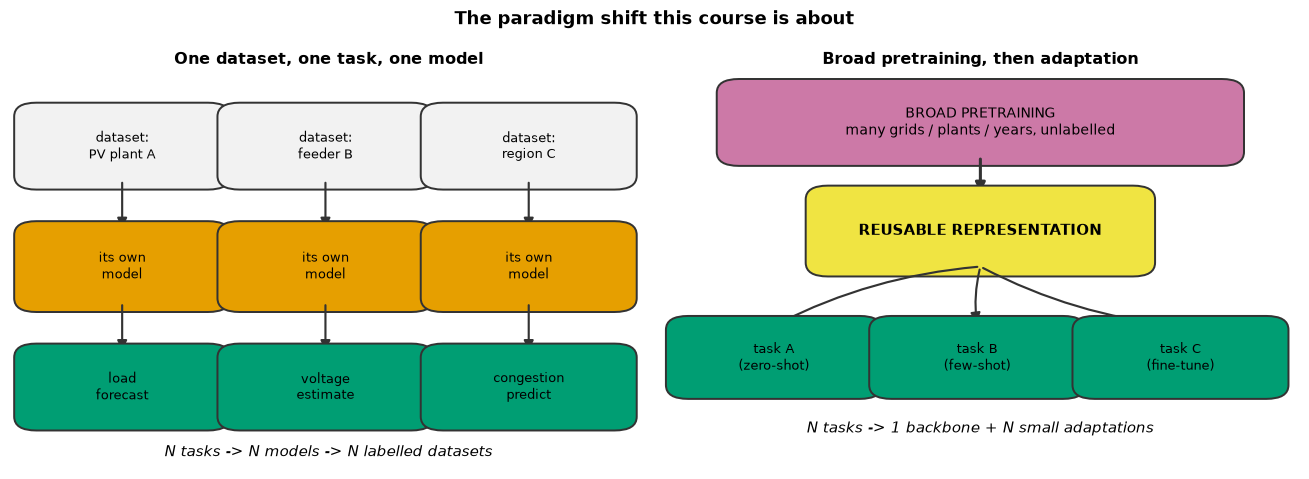

In [3]:
fig = diagrams.paradigm_shift()
plt.show()

## 5. Foundation models across domains

Read the "pretraining objective" column downwards. Almost all of it is
*reconstruct something hidden* or *predict the next thing*. That is the whole
trick, applied to different data.

,models,input representation,pretraining objective,architecture,downstream tasks
domain,,,,,
language / code,"GPT, Llama, Mistral, Qwen",subword tokens,next-token prediction,decoder Transformer,"generation, QA, code"
vision (self-sup.),DINOv2,image patches,"self-distillation, no labels",ViT,"classification, segmentation, depth"
vision-language,CLIP,image + text pairs,contrastive alignment,dual encoder,"zero-shot classification, retrieval"
segmentation,"SAM, SAM 2",image/video + prompt,supervised on auto-labelled data,ViT + prompt decoder,promptable segmentation
biology (sequence),ESM-2,amino-acid tokens,masked language modelling,encoder Transformer,"structure, function, variants"
biology (structure),AlphaFold 2/3,sequence + MSA,supervised on the PDB,Evoformer,structure prediction
weather,GraphCast,gridded atmospheric state,next-state prediction,graph neural network,medium-range forecasting
weather,"Aurora, GenCast",gridded state,masked / diffusion,"3D Swin, diffusion","multi-variable, ensembles"
time series,Chronos-2,numeric context + covariates,quantile forecasting over broad corpora,encoder Transformer,zero-shot forecasting


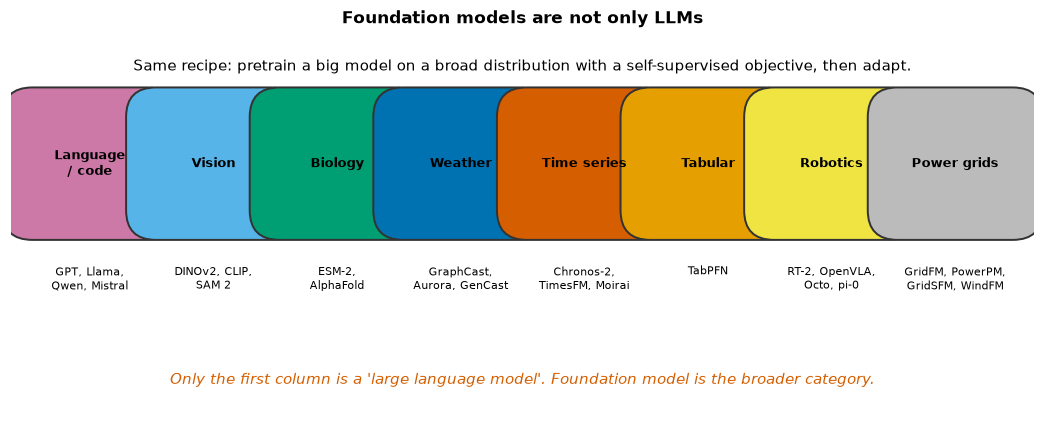

In [4]:
domains = pd.DataFrame(
    [
        ("language / code", "GPT, Llama, Mistral, Qwen", "subword tokens",
         "next-token prediction", "decoder Transformer", "generation, QA, code"),
        ("vision (self-sup.)", "DINOv2", "image patches",
         "self-distillation, no labels", "ViT", "classification, segmentation, depth"),
        ("vision-language", "CLIP", "image + text pairs",
         "contrastive alignment", "dual encoder", "zero-shot classification, retrieval"),
        ("segmentation", "SAM, SAM 2", "image/video + prompt",
         "supervised on auto-labelled data", "ViT + prompt decoder",
         "promptable segmentation"),
        ("biology (sequence)", "ESM-2", "amino-acid tokens",
         "masked language modelling", "encoder Transformer",
         "structure, function, variants"),
        ("biology (structure)", "AlphaFold 2/3", "sequence + MSA",
         "supervised on the PDB", "Evoformer", "structure prediction"),
        ("weather", "GraphCast", "gridded atmospheric state",
         "next-state prediction", "graph neural network", "medium-range forecasting"),
        ("weather", "Aurora, GenCast", "gridded state", "masked / diffusion",
         "3D Swin, diffusion", "multi-variable, ensembles"),
        ("time series", "Chronos-2", "numeric context + covariates",
         "quantile forecasting over broad corpora", "encoder Transformer",
         "zero-shot forecasting"),
        ("time series", "TimesFM, Moirai, MOMENT, TTM", "patches of steps",
         "next-patch / masked", "decoder or encoder",
         "forecasting, imputation, anomalies"),
        ("tabular", "TabPFN", "a whole small table",
         "trained on synthetic datasets", "encoder Transformer",
         "in-context classification"),
        ("robotics", "RT-2, OpenVLA, Octo, pi-0", "images + language + state",
         "action prediction from demos", "VLM + action head", "manipulation, control"),
        ("power grids", "GridFM, PowerPM, GridSFM, WindFM", "graphs, ETS, states",
         "masked reconstruction + physics", "graph Transformer / GNN",
         "power flow, OPF, forecasting"),
    ],
    columns=["domain", "models", "input representation", "pretraining objective",
             "architecture", "downstream tasks"],
).set_index("domain")
display(domains)

fig = diagrams.foundation_model_modalities()
plt.show()

### Two case studies worth knowing in detail

**DINOv2** (Oquab et al., 2023) is the cleanest counter-example to "foundation
model = generative model". It is trained by self-distillation on 142 million
curated images with **no labels and no text**, and produces features so good
that a *linear* classifier on frozen DINOv2 features beats fully fine-tuned
specialist models on several benchmarks. It generates nothing whatsoever.

**TabPFN** (Hollmann et al., 2022) breaks two assumptions at once. It is
pretrained entirely on **synthetic** datasets drawn from a prior over causal
structures, and at inference it takes an entire small table as its *context*
and classifies in one forward pass — in-context learning, on tables, with no
gradient step. It is small enough to run on a laptop.

If your mental model of "foundation model" cannot accommodate both of these,
it is a mental model of LLMs.

## 6. The experiment

**Zero-shot day-ahead load forecasting with Chronos-2**, against the
specialists this course has already built.

Chronos-2 (Ansari et al., 2025) is 120 M parameters, encoder-only, and was
pretrained on a large mixture of real and synthetic time series from many
domains. It forecasts a series it has never seen, in one forward pass, with no
training. Apache-2.0, runs on CPU.

### Why our synthetic dataset is an advantage here

Chronos-2's pretraining corpus certainly contains public electricity data —
possibly including the very OPSD series this course optionally downloads. On a
public benchmark we could not rule out **contamination**, and "zero-shot"
would be an unverifiable claim.

Our default dataset is generated by this repository. It cannot have been in
anyone's pretraining set. That makes this one of the rare genuinely clean
zero-shot evaluations you will see, and it is worth understanding why that is
rare.

In [5]:
dataset = load_energy_data()
print(dataset.describe())
frame = dataset.frame
train_raw, valid_raw, test_raw = time_split(frame)

CONTEXT = 512          # what we hand the foundation model
HORIZON = 24
QUANTILES = [0.1, 0.5, 0.9]

# One forecast per day, issued at 00:00 UTC — a realistic day-ahead cadence, and
# 365 forecasts rather than 8,760 overlapping ones.
origins = test_raw.index[(test_raw.index.hour == 0)]
origins = origins[origins >= frame.index[0] + pd.Timedelta(hours=CONTEXT)]
origins = origins[origins + pd.Timedelta(hours=HORIZON) <= frame.index[-1]]
if fast_mode():
    origins = origins[:20]
print(f"\n{len(origins)} daily forecast origins, {origins[0]:%Y-%m-%d} to {origins[-1]:%Y-%m-%d}")

series = frame.load_mw
positions = series.index.get_indexer(origins)
contexts = np.stack([series.to_numpy()[p - CONTEXT + 1 : p + 1] for p in positions])
targets = np.stack([series.to_numpy()[p + 1 : p + 1 + HORIZON] for p in positions])
print(f"contexts {contexts.shape}   targets {targets.shape}")

DATA PROVENANCE: SIMULATED (not measurements)
  source   : synthetic
  title    : Synthetic European power-system time series (ai_power_course.synthetic)
  license  : MIT (generated by this repository)
  cite as  : Generated by ai_power_course.synthetic.generate_energy_frame, seed 20260101.
  notes    : Physically motivated simulation. Magnitudes are tuned to resemble Germany (~479 TWh/a load, PV CF 0.12, wind CF 0.20) but no value is a measurement.
rows      : 35,064 (2017-01-01 to 2020-12-31, h)
columns   : load_mw, pv_mw, wind_mw, residual_load_mw, price_eur_mwh, temperature_c, wind_speed_ms, clear_sky_index, is_night, is_weekend, is_holiday

365 daily forecast origins, 2020-01-01 to 2020-12-30
contexts (365, 512)   targets (365, 24)


### 6.1 The baselines and the specialists

Everything is evaluated on exactly these 365 × 24 target values.

In [6]:
predictions: dict[str, np.ndarray] = {}

# Trivial baselines.
predictions["Persistence (flat)"] = np.repeat(contexts[:, -1:], HORIZON, axis=1)
predictions["Seasonal naive (168 h)"] = np.stack(
    [series.to_numpy()[p + 1 - 168 : p + 1 - 168 + HORIZON] for p in positions]
)

for name, values in predictions.items():
    print(f"{name:24s} MAE {mae(targets.ravel(), values.ravel()):8,.1f} MW")

Persistence (flat)       MAE  7,531.2 MW
Seasonal naive (168 h)   MAE  2,257.4 MW


In [7]:
# Specialist 1: gradient boosting, one model per lead time ("direct" strategy).
# It is trained on 2017-2019 and sees the same 512-hour context, flattened.
set_seed()
fit_origins = frame.index[(frame.index.hour == 0) & (frame.index < test_raw.index[0])]
fit_origins = fit_origins[fit_origins >= frame.index[0] + pd.Timedelta(hours=CONTEXT)]
fit_positions = series.index.get_indexer(fit_origins)
# Drop any origin whose horizon would run past the end of the series, and keep
# the timestamps in lock-step with the positions — they are used together below.
keep = fit_positions + HORIZON < len(series)
fit_origins, fit_positions = fit_origins[keep], fit_positions[keep]
fit_contexts = np.stack([series.to_numpy()[p - CONTEXT + 1 : p + 1] for p in fit_positions])
fit_targets = np.stack([series.to_numpy()[p + 1 : p + 1 + HORIZON] for p in fit_positions])

# Give it a compact, sensible feature set rather than 512 raw lags.
def boosting_features(windows: np.ndarray, stamps: pd.DatetimeIndex) -> np.ndarray:
    recent = windows[:, -48:]
    return np.column_stack([
        windows[:, -1], windows[:, -24], windows[:, -168],
        recent.mean(axis=1), recent.std(axis=1),
        windows[:, -168:].mean(axis=1),
        stamps.dayofweek.to_numpy(), stamps.dayofyear.to_numpy(),
    ])


started = time.perf_counter()
X_fit = boosting_features(fit_contexts, fit_origins)
X_test = boosting_features(contexts, origins)
boosting = np.zeros_like(targets)
for lead in range(HORIZON):
    model = HistGradientBoostingRegressor(
        max_iter=scaled(full=150, fast=30), learning_rate=0.08, random_state=0
    ).fit(X_fit, fit_targets[:, lead])
    boosting[:, lead] = model.predict(X_test)
boosting_seconds = time.perf_counter() - started
predictions["Gradient boosting (specialist)"] = boosting
print(f"gradient boosting: 24 models, {boosting_seconds:.0f}s, "
      f"MAE {mae(targets.ravel(), boosting.ravel()):,.1f} MW")

gradient boosting: 24 models, 9s, MAE 1,300.8 MW


In [8]:
# Specialist 2: an LSTM on the same windows.
set_seed()
scaler = Standardizer().fit(fit_contexts.reshape(-1, 1))
x_fit = scaler.transform(fit_contexts).reshape(len(fit_contexts), CONTEXT, 1)
x_test = scaler.transform(contexts).reshape(len(contexts), CONTEXT, 1)
target_scaler = Standardizer().fit(fit_targets)
y_fit = target_scaler.transform(fit_targets)

split = int(0.85 * len(x_fit))
lstm = LSTMForecaster(1, hidden_size=64, num_layers=1, horizon=HORIZON)
started = time.perf_counter()
train_model(
    lstm,
    make_loader(x_fit[:split], y_fit[:split], batch_size=32, shuffle=True),
    make_loader(x_fit[split:], y_fit[split:], batch_size=64),
    loss_fn=nn.MSELoss(),
    config=TrainConfig(epochs=scaled(full=60, fast=3), learning_rate=2e-3,
                       patience=10, verbose=False),
)
lstm_seconds = time.perf_counter() - started
predictions["LSTM (specialist)"] = target_scaler.inverse_transform(predict(lstm, x_test))
print(f"LSTM: {count_parameters(lstm):,} parameters, {lstm_seconds:.0f}s, "
      f"MAE {mae(targets.ravel(), predictions['LSTM (specialist)'].ravel()):,.1f} MW")

LSTM: 18,712 parameters, 101s, MAE 1,256.9 MW


### 6.2 The foundation model, zero-shot

No training. No fine-tuning. We hand it 512 numbers and ask for 24.

In [9]:
chronos_quantiles = None
chronos_seconds = float("nan")
if not offline_mode():
    try:
        from chronos import Chronos2Pipeline

        started = time.perf_counter()
        pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")
        load_seconds = time.perf_counter() - started
        chronos_params = sum(p.numel() for p in pipeline.model.parameters())
        print(f"amazon/chronos-2 loaded in {load_seconds:.0f}s: "
              f"{chronos_params / 1e6:.1f} M parameters, Apache-2.0")

        started = time.perf_counter()
        quantile_list, mean_list = pipeline.predict_quantiles(
            [torch.tensor(row, dtype=torch.float32) for row in contexts],
            prediction_length=HORIZON,
            quantile_levels=QUANTILES,
            batch_size=32,
        )
        chronos_seconds = time.perf_counter() - started
        # Each element: (n_variates, horizon, n_quantiles); univariate -> squeeze.
        chronos_quantiles = torch.stack([q[0] for q in quantile_list]).numpy()
        predictions["Chronos-2 (zero-shot)"] = chronos_quantiles[:, :, QUANTILES.index(0.5)]
        print(f"forecast {len(contexts)} series in {chronos_seconds:.0f}s "
              f"({chronos_seconds / len(contexts) * 1000:.0f} ms each)")
        print(f"MAE {mae(targets.ravel(), predictions['Chronos-2 (zero-shot)'].ravel()):,.1f} MW")
    except Exception as exc:  # noqa: BLE001
        print(f"Chronos-2 unavailable ({type(exc).__name__}: {str(exc)[:200]})")
        print("The comparison below will run without it.")

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

amazon/chronos-2 loaded in 1s: 119.5 M parameters, Apache-2.0


forecast 365 series in 6s (15 ms each)
MAE 1,350.9 MW


## 7. Results

,MAE,RMSE,R2,Bias,MAPE_%,Skill
LSTM (specialist),1256.881,1652.107,0.941,41.453,2.374,0.452
Gradient boosting (specialist),1300.824,1700.228,0.938,285.772,2.451,0.436
Chronos-2 (zero-shot),1350.941,1788.073,0.931,-10.588,2.544,0.407
Seasonal naive (168 h),2257.378,3013.805,0.804,-27.102,4.186,0.000
Persistence (flat),7531.237,8591.418,-0.595,-6821.426,13.466,-1.851


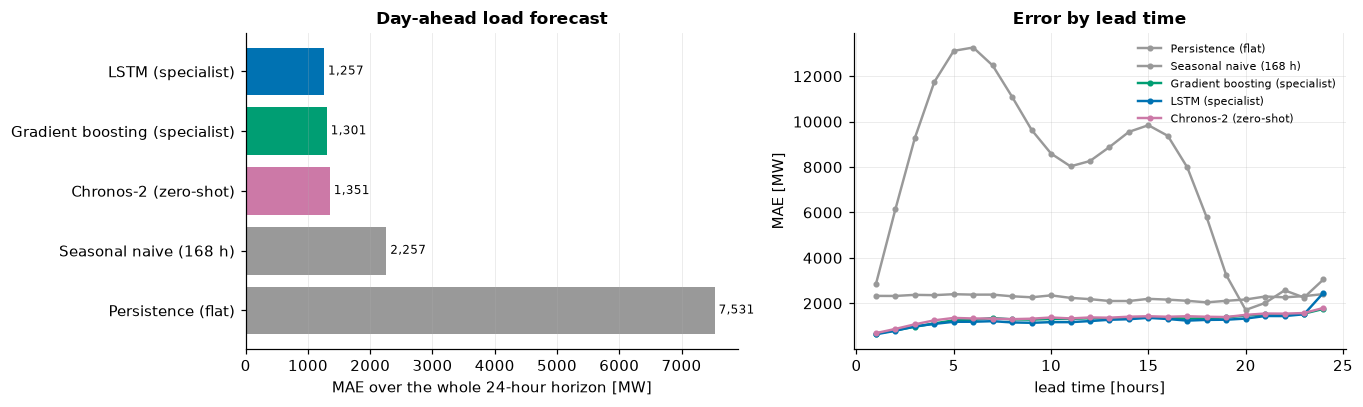

In [10]:
reference = predictions["Seasonal naive (168 h)"]
results = pd.DataFrame(
    {
        name: {
            **point_metrics(targets.ravel(), values.ravel(), include_mape=True),
            "Skill": skill_score(targets.ravel(), values.ravel(), reference.ravel()),
        }
        for name, values in predictions.items()
    }
).T.sort_values("MAE")
display(results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
colors = {
    "Persistence (flat)": COLORS["baseline"],
    "Seasonal naive (168 h)": COLORS["baseline"],
    "Gradient boosting (specialist)": COLORS["tree"],
    "LSTM (specialist)": COLORS["rnn"],
    "Chronos-2 (zero-shot)": COLORS["foundation"],
}
ordered = results.MAE.sort_values(ascending=False)
axes[0].barh(ordered.index, ordered.to_numpy(),
             color=[colors.get(n, COLORS["mlp"]) for n in ordered.index])
axes[0].set_xlabel("MAE over the whole 24-hour horizon [MW]")
axes[0].set_title("Day-ahead load forecast")
axes[0].grid(axis="y", visible=False)
for y_pos, value in enumerate(ordered.to_numpy()):
    axes[0].text(value, y_pos, f" {value:,.0f}", va="center", fontsize=8)

for name, values in predictions.items():
    per_lead = [mae(targets[:, h], values[:, h]) for h in range(HORIZON)]
    axes[1].plot(range(1, HORIZON + 1), per_lead, marker="o", ms=3, label=name,
                 color=colors.get(name, COLORS["mlp"]))
axes[1].set_xlabel("lead time [hours]")
axes[1].set_ylabel("MAE [MW]")
axes[1].set_title("Error by lead time")
axes[1].legend(fontsize=7.5)
fig.tight_layout()
plt.show()

In [11]:
best = results.index[0]
print(f"Best: {best}  (MAE {results.MAE.iloc[0]:,.0f} MW)")
if "Chronos-2 (zero-shot)" in results.index:
    chronos_mae = results.loc["Chronos-2 (zero-shot)", "MAE"]
    for specialist in ("Gradient boosting (specialist)", "LSTM (specialist)"):
        if specialist in results.index:
            gap = chronos_mae / results.loc[specialist, "MAE"] - 1
            word = "higher" if gap > 0 else "lower"
            print(f"Chronos-2 vs. {specialist:32s} {abs(gap):5.1%} {word} MAE")
    print(f"\nTraining cost: gradient boosting {boosting_seconds:.0f}s, LSTM {lstm_seconds:.0f}s, "
          f"Chronos-2 0s (zero-shot).")
    print(f"Inference cost: Chronos-2 {chronos_seconds / len(contexts) * 1000:.0f} ms per forecast")
    print("                specialists  well under 1 ms per forecast")

Best: LSTM (specialist)  (MAE 1,257 MW)
Chronos-2 vs. Gradient boosting (specialist)    3.9% higher MAE
Chronos-2 vs. LSTM (specialist)                 7.5% higher MAE

Training cost: gradient boosting 9s, LSTM 101s, Chronos-2 0s (zero-shot).
Inference cost: Chronos-2 15 ms per forecast
                specialists  well under 1 ms per forecast


**However this comes out, read it with the costs attached.** The specialists
saw three years of *this* system's history. Chronos-2 saw none of it. If it is
within a modest factor of a tuned specialist without a single gradient step,
that is a remarkable statement about transfer — and it is a completely
different value proposition from "it is more accurate".

The situation where that matters is not this one. It is the new site with two
weeks of data, the feeder that was just instrumented, the thousand substations
you cannot individually tune. That is what reusable representations buy.

## 8. Probabilistic evaluation

A point forecast is an impoverished object. Chronos-2 emits quantiles
natively, which lets us ask whether its *uncertainty* is honest — a different
question from whether its median is close, and often the more operationally
important one.

In [12]:
if chronos_quantiles is not None:
    flat_targets = targets.ravel()
    flat_quantiles = chronos_quantiles.reshape(-1, len(QUANTILES))

    probabilistic = {
        "CRPS (approx.)": crps_from_quantiles(flat_targets, flat_quantiles, QUANTILES),
        "pinball q10": pinball_loss(flat_targets, flat_quantiles[:, 0], 0.1),
        "pinball q50": pinball_loss(flat_targets, flat_quantiles[:, 1], 0.5),
        "pinball q90": pinball_loss(flat_targets, flat_quantiles[:, 2], 0.9),
        "coverage of the 80% interval": coverage(
            flat_targets, flat_quantiles[:, 0], flat_quantiles[:, 2]
        ),
        "mean interval width [MW]": float(
            (flat_quantiles[:, 2] - flat_quantiles[:, 0]).mean()
        ),
    }
    for key, value in probabilistic.items():
        print(f"  {key:30s} {value:10,.3f}")

    nominal = QUANTILES[-1] - QUANTILES[0]
    empirical = probabilistic["coverage of the 80% interval"]
    verdict = ("well calibrated" if abs(empirical - nominal) < 0.05
               else "over-confident" if empirical < nominal else "under-confident")
    print(f"\nNominal coverage {nominal:.0%}, empirical {empirical:.1%} -> {verdict}.")
    print("\nCalibration is not accuracy. A model can have the best median in the table")
    print("and intervals that are systematically too narrow, which in an operational")
    print("setting is worse than a slightly worse median with honest uncertainty.")

  CRPS (approx.)                    906.955
  pinball q10                       305.646
  pinball q50                       675.470
  pinball q90                       305.318
  coverage of the 80% interval        0.780
  mean interval width [MW]        4,245.307

Nominal coverage 80%, empirical 78.0% -> well calibrated.

Calibration is not accuracy. A model can have the best median in the table
and intervals that are systematically too narrow, which in an operational
setting is worse than a slightly worse median with honest uncertainty.


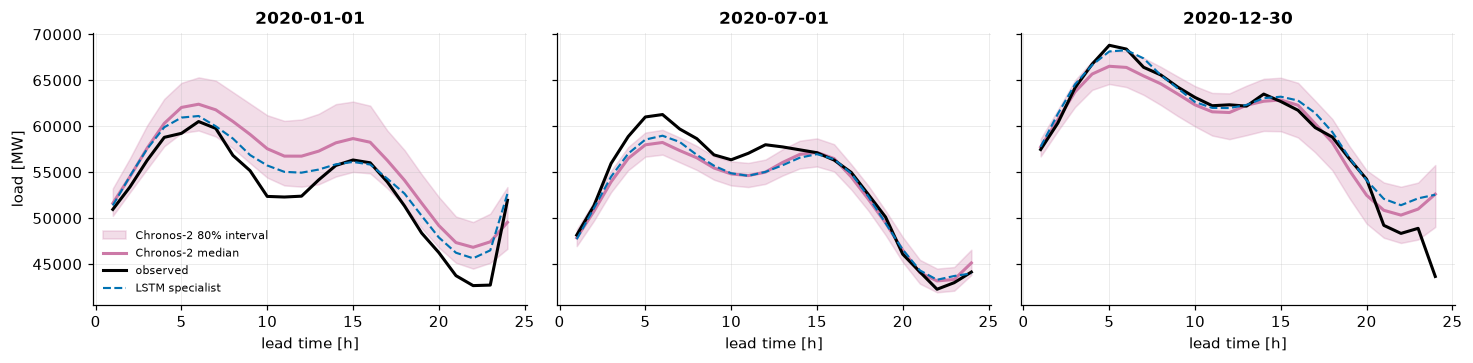

In [13]:
if chronos_quantiles is not None:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.4), sharey=True)
    picks = np.linspace(0, len(origins) - 1, 3).astype(int)
    hours = np.arange(1, HORIZON + 1)
    for ax, index in zip(axes, picks, strict=True):
        ax.fill_between(hours, chronos_quantiles[index, :, 0], chronos_quantiles[index, :, 2],
                        color=COLORS["foundation"], alpha=0.25, label="Chronos-2 80% interval")
        ax.plot(hours, chronos_quantiles[index, :, 1], color=COLORS["foundation"],
                lw=2, label="Chronos-2 median")
        ax.plot(hours, targets[index], color=COLORS["truth"], lw=2, label="observed")
        if "LSTM (specialist)" in predictions:
            ax.plot(hours, predictions["LSTM (specialist)"][index], color=COLORS["rnn"],
                    lw=1.4, ls="--", label="LSTM specialist")
        ax.set_title(f"{origins[index]:%Y-%m-%d}")
        ax.set_xlabel("lead time [h]")
    axes[0].set_ylabel("load [MW]")
    axes[0].legend(fontsize=7.5)
    fig.tight_layout()
    plt.show()

## 9. Where the foundation model loses

The section the notebook exists for. We move to **PV generation**, which has
two properties load does not: a hard physical zero at night, and an
overwhelming exogenous driver (the sun) that is perfectly predictable from the
calendar and invisible in the history.

In [14]:
pv_series = frame.pv_mw
pv_contexts = np.stack([pv_series.to_numpy()[p - CONTEXT + 1 : p + 1] for p in positions])
pv_targets = np.stack([pv_series.to_numpy()[p + 1 : p + 1 + HORIZON] for p in positions])
night_mask = np.stack([frame.is_night.to_numpy()[p + 1 : p + 1 + HORIZON] for p in positions])

pv_fit_contexts = np.stack([pv_series.to_numpy()[p - CONTEXT + 1 : p + 1] for p in fit_positions])
pv_fit_targets = np.stack([pv_series.to_numpy()[p + 1 : p + 1 + HORIZON] for p in fit_positions])

pv_predictions: dict[str, np.ndarray] = {
    "Seasonal naive (24 h)": np.stack(
        [pv_series.to_numpy()[p + 1 - 24 : p + 1 - 24 + HORIZON] for p in positions]
    )
}

# A specialist that is *given the covariate*: the clear-sky index for the hours
# being predicted. This is known perfectly in advance from solar geometry.
clear_sky = np.stack(
    [frame.clear_sky_index.to_numpy()[p + 1 : p + 1 + HORIZON] for p in positions]
)
fit_clear_sky = np.stack(
    [frame.clear_sky_index.to_numpy()[p + 1 : p + 1 + HORIZON] for p in fit_positions]
)

set_seed()
pv_boosting = np.zeros_like(pv_targets)
for lead in range(HORIZON):
    features_fit = np.column_stack([
        pv_fit_contexts[:, -1], pv_fit_contexts[:, -24], pv_fit_contexts[:, -168:].mean(axis=1),
        fit_clear_sky[:, lead], fit_origins.dayofyear.to_numpy(),
    ])
    features_test = np.column_stack([
        pv_contexts[:, -1], pv_contexts[:, -24], pv_contexts[:, -168:].mean(axis=1),
        clear_sky[:, lead], origins.dayofyear.to_numpy(),
    ])
    model = HistGradientBoostingRegressor(
        max_iter=scaled(full=150, fast=30), learning_rate=0.08, random_state=0
    ).fit(features_fit, pv_fit_targets[:, lead])
    pv_boosting[:, lead] = model.predict(features_test)
pv_predictions["Gradient boosting + clear-sky covariate"] = np.clip(pv_boosting, 0, None)

if not offline_mode() and chronos_quantiles is not None:
    started = time.perf_counter()
    pv_quantile_list, _ = pipeline.predict_quantiles(
        [torch.tensor(row, dtype=torch.float32) for row in pv_contexts],
        prediction_length=HORIZON, quantile_levels=QUANTILES, batch_size=32,
    )
    pv_chronos = torch.stack([q[0] for q in pv_quantile_list]).numpy()
    pv_predictions["Chronos-2 zero-shot (no covariate)"] = pv_chronos[:, :, 1]
    print(f"Chronos-2 on PV: {time.perf_counter() - started:.0f}s")

# And the same specialist with the physics applied: clip at zero, and force the
# night hours to zero. Both facts are known exactly, in advance, for free.
constrained = pv_predictions["Gradient boosting + clear-sky covariate"].copy()
constrained = np.clip(constrained, 0.0, 45_000.0)
constrained[night_mask] = 0.0
pv_predictions["Gradient boosting + covariate + physics"] = constrained

pv_results = pd.DataFrame(
    {name: {"MAE": mae(pv_targets.ravel(), values.ravel()),
            "RMSE": rmse(pv_targets.ravel(), values.ravel())}
     for name, values in pv_predictions.items()}
).T.sort_values("MAE")
display(pv_results.round(1))

Chronos-2 on PV: 5s


,MAE,RMSE
Gradient boosting + covariate + physics,1685.9,3347.9
Chronos-2 zero-shot (no covariate),1686.0,3326.7
Gradient boosting + clear-sky covariate,1686.5,3347.9
Seasonal naive (24 h),1741.8,3690.5


In [15]:
# The physical question, which no error metric above answers.
print("Physical validity of each PV forecast:\n")
physics_rows = {}
for name, values in pv_predictions.items():
    report = physical_violations(
        values.ravel(), lower_bound=0.0, upper_bound=45_000.0,
        zero_mask=night_mask.ravel(),
    )
    physics_rows[name] = {
        "negative-generation rate": report["below_min_rate"],
        "non-zero at night rate": report["nonzero_when_impossible_rate"],
        "worst night-time value [MW]": report["worst_impossible_value"],
    }
display(pd.DataFrame(physics_rows).T.round(4))

Physical validity of each PV forecast:



,negative-generation rate,non-zero at night rate,worst night-time value [MW]
Seasonal naive (24 h),0.0000,0.0023,85.9050
Gradient boosting + clear-sky covariate,0.0000,0.3168,216.3816
Chronos-2 zero-shot (no covariate),0.0076,1.0000,1006.2515
Gradient boosting + covariate + physics,0.0000,0.0000,0.0000


In [16]:
pv_mae = pv_results.MAE
chronos_key = "Chronos-2 zero-shot (no covariate)"
if chronos_key in pv_mae.index:
    print(f"Chronos-2 zero-shot            MAE {pv_mae[chronos_key]:8,.1f} MW")
print(f"specialist + covariate         MAE "
      f"{pv_mae['Gradient boosting + clear-sky covariate']:8,.1f} MW")
print(f"specialist + covariate + physics MAE "
      f"{pv_mae['Gradient boosting + covariate + physics']:8,.1f} MW")
print("\nAnd the same three, as physical states:")
for name in pv_predictions:
    report = physical_violations(pv_predictions[name].ravel(), lower_bound=0.0,
                                 zero_mask=night_mask.ravel())
    print(f"  {name:42s} non-zero at night {report['nonzero_when_impossible_rate']:6.1%}"
          f"   worst {report['worst_impossible_value']:7,.0f} MW")

Chronos-2 zero-shot            MAE  1,686.0 MW
specialist + covariate         MAE  1,686.5 MW
specialist + covariate + physics MAE  1,685.9 MW

And the same three, as physical states:
  Seasonal naive (24 h)                      non-zero at night   0.2%   worst      86 MW
  Gradient boosting + clear-sky covariate    non-zero at night  31.7%   worst     216 MW
  Chronos-2 zero-shot (no covariate)         non-zero at night 100.0%   worst   1,006 MW
  Gradient boosting + covariate + physics    non-zero at night   0.0%   worst       0 MW


**This is the honest picture of a foundation model's limits — and it is not
the picture most people expect.**

On **MAE**, the zero-shot foundation model and the covariate-informed
specialist are essentially tied. That alone is remarkable: one of them was
given the clear-sky index for the hours it was predicting and three years of
this plant's history, and the other was given 512 numbers and nothing else.

On **physical validity** they are not close at all. Look at the night-time
column:

- Chronos-2 produces non-zero PV generation in **every single night hour**,
  with excursions of hundreds of megawatts. It has no reason not to: nothing
  in a general-purpose forecasting objective encodes "the sun sets".
- The specialist does better, because the clear-sky covariate tells it, but
  still leaks at dawn and dusk.
- Applying the constraint explicitly — clip at zero, force the night hours to
  zero — removes the violations entirely **and improves the MAE**, because the
  errors it was removing were real errors.

So the correct summary is not "the specialist is more accurate". It is:

> **Two forecasts with the same MAE can be physically very different, and no
> error metric will tell you which.** The foundation model's output is not a
> realisable PV schedule. The constrained specialist's is.

This is tutorial 01's lesson, arriving eight notebooks later at a much larger
model, and it is the reason this course evaluates physics separately.

### Where each one belongs

| condition | favours |
|---|---|
| a strong known covariate you can supply | the specialist (or Chronos-2 *with* covariates) |
| hard physical constraints | whichever model you constrain — do it explicitly |
| plenty of in-distribution history | the specialist |
| an unusual resolution or horizon | the specialist, if you have data for it |
| tight latency or memory budgets | the specialist: 19 k parameters against 119 M |
| **no history at all for this series** | **the foundation model — nothing else runs** |
| **thousands of series and no budget to tune each** | **the foundation model** |
| **calibrated uncertainty needed immediately** | **the foundation model: quantiles are free** |

### One more thing, and it is a user error worth naming

We ran Chronos-2 **univariate** on a series whose dominant driver is a known
covariate. Chronos-2 accepts covariates through `predict_df`; using the
univariate call here handicaps it, and doing that by accident is extremely
common. Exercise 1 asks you to fix it and measure how much of the gap closes —
and how much of the *physical* violation does not, because covariates do not
impose constraints either.

## 10. "Zero-shot" does not mean "never seen anything similar"

Chronos-2's pretraining corpus is large, mixed, and only partly documented. It
very likely contains electricity demand series. Our evaluation is clean only
because the data is generated by this repository — a luxury you will not
usually have.

In [17]:
contamination = pd.DataFrame(
    {
        "could it be in a pretraining corpus?": [
            "almost certainly", "almost certainly", "possibly",
            "no — generated by this repository",
        ],
        "what a zero-shot claim means there": [
            "very little", "very little",
            "unclear without the corpus manifest", "exactly what it says",
        ],
    },
    index=["a public benchmark (ETT, ECL, Traffic)", "OPSD / ENTSO-E series",
           "your utility's published aggregates", "this course's synthetic series"],
)
display(contamination)

print("Three things to do about it, in order of strength:\n")
print("  1. Evaluate on data that provably post-dates the model, or that you generated.")
print("  2. Check the model card and the corpus manifest, and say what you found.")
print("  3. At minimum, state the risk explicitly rather than claiming 'zero-shot'")
print("     and moving on.")
print("\nThe same problem afflicts LLM benchmarks, where it is now well documented")
print("and routinely ignored.")

,could it be in a pretraining corpus?,what a zero-shot claim means there
"a public benchmark (ETT, ECL, Traffic)",almost certainly,very little
OPSD / ENTSO-E series,almost certainly,very little
your utility's published aggregates,possibly,unclear without the corpus manifest
this course's synthetic series,no — generated by this repository,exactly what it says


Three things to do about it, in order of strength:

  1. Evaluate on data that provably post-dates the model, or that you generated.
  2. Check the model card and the corpus manifest, and say what you found.
  3. At minimum, state the risk explicitly rather than claiming 'zero-shot'
     and moving on.

The same problem afflicts LLM benchmarks, where it is now well documented
and routinely ignored.


## 11. Record the result

In [18]:
Leaderboard().clear(tutorial=9)
for name, values in predictions.items():
    if "specialist" in name or "zero-shot" in name:
        record(
            model=name,
            tutorial=9,
            task="load_day_ahead_daily_origins",
            metrics={
                **point_metrics(targets.ravel(), values.ravel()),
                "Skill": skill_score(targets.ravel(), values.ravel(), reference.ravel()),
            },
            notes=f"{len(origins)} daily origins, {CONTEXT} h context, full 24 h horizon",
        )
display(leaderboard_table(task="load_day_ahead_daily_origins"))

print("\nNote the separate task name. This evaluation uses daily origins and scores the")
print("whole 24-hour horizon; tutorials 01-06 used hourly origins and scored t+24 only.")
print("Mixing them in one table would be comparing different numbers — which is the")
print("most common way benchmark tables mislead.")

Bias       MAE  MAPE_%     R2  \
Tutorial Model                                                              
9        LSTM (specialist)                41.453  1256.881   2.374  0.941   
         Gradient boosting (specialist)  285.772  1300.824   2.451  0.938   
         Chronos-2 (zero-shot)           -10.588  1350.941   2.544  0.931   

                                             RMSE  Skill  \
Tutorial Model                                             
9        LSTM (specialist)               1652.107  0.452   
         Gradient boosting (specialist)  1700.228  0.436   
         Chronos-2 (zero-shot)           1788.073  0.407   

                                                                                     Notes  \
Tutorial Model                                                                               
9        LSTM (specialist)               365 daily origins, 512 h context, full 24 h ho...   
         Gradient boosting (specialist)  365 daily origins, 512 h context, full 24 h ho...   
         Chronos-2 (zero-shot)           365 daily origins, 512 h context, full 24 h ho...   

                                         Reference_RMSE  
Tutorial Model                                           
9        LSTM (specialist)                     3013.805  
         Gradient boosting (specialist)        3013.805  
         Chronos-2 (zero-shot)                 3013.805


Note the separate task name. This evaluation uses daily origins and scores the
whole 24-hour horizon; tutorials 01-06 used hourly origins and scored t+24 only.
Mixing them in one table would be comparing different numbers — which is the
most common way benchmark tables mislead.


## 12. Exercises

**1 — Conceptual.** Section 9 ran Chronos-2 univariate on a series driven by a
known covariate, and it lost. Before implementing anything, predict how much of
the gap `predict_df` with the clear-sky index as a future covariate would
close, and say what would remain. Then implement it and check. Where you were
wrong, say why.

**2 — Coding.** Compare zero-shot Chronos-2 against the specialists under
deliberate distribution shift. Construct three shifted test sets from the
synthetic generator: (a) a 20% higher load level, (b) doubled noise, (c) a
15-minute resolution instead of hourly. Report MAE for each method on each.
Which degrades most gracefully, and does that match your intuition about what
each model is relying on?

**3 — Research.** Read arXiv:2604.22077 ("Empirical Assessment of Time-Series
Foundation Models For Power System Forecasting Applications") and
arXiv:2604.22328 (the FETS benchmark) together. They do not entirely agree.
Write two pages identifying *why*: which horizons, resolutions, covariate
settings and baseline-tuning choices differ, and which of their conclusions
your own experiment in this notebook supports. This is the assignment the
tutorial is built towards.

## 13. Key takeaways

- **A foundation model is defined by breadth of pretraining and breadth of
  adaptability**, not by size, generativity, language, or architecture.
- **Most foundation models are not LLMs.** DINOv2 generates nothing; TabPFN was
  pretrained on synthetic tables; WindFM has 8.1 M parameters.
- **Zero-shot transfer is real and measurable.** A model that saw none of our
  data produced a competitive day-ahead forecast in one forward pass.
- **But a matched MAE can hide a physically impossible forecast.** On PV,
  Chronos-2 tied a covariate-informed specialist on error and produced non-zero
  generation in *every* night hour. Constraining the specialist removed the
  violations and improved its MAE at the same time.
- **Evaluate uncertainty, not just the median.** Coverage and CRPS answer a
  question MAE cannot.
- **"Zero-shot" is a claim about the evaluation, not about the model.** Without
  knowing the pretraining corpus you cannot verify it; our synthetic dataset is
  the rare case where you can.

## 14. Further reading

- Bommasani et al., "On the Opportunities and Risks of Foundation Models",
  [arXiv:2108.07258](https://arxiv.org/abs/2108.07258).
- Ansari et al., "Chronos-2: From Univariate to Universal Forecasting",
  [arXiv:2510.15821](https://arxiv.org/abs/2510.15821); model card at
  <https://huggingface.co/amazon/chronos-2>.
- Oquab et al., "DINOv2", [arXiv:2304.07193](https://arxiv.org/abs/2304.07193).
- Hollmann et al., "TabPFN", [arXiv:2207.01848](https://arxiv.org/abs/2207.01848).
- Ekambaram et al., "Tiny Time Mixers",
  [arXiv:2401.03955](https://arxiv.org/abs/2401.03955) — small foundation models.
- Gneiting & Raftery, "Strictly Proper Scoring Rules, Prediction, and
  Estimation", *JASA* 102(477), 2007 — the theory behind CRPS.
- "Empirical Assessment of Time-Series Foundation Models For Power System
  Forecasting Applications", [arXiv:2604.22077](https://arxiv.org/abs/2604.22077).

---

**Next:** [Tutorial 10 — Toward Foundation Models for the Electric Power
Grid](10_grid_foundation_models.ipynb). Time series are the easy modality.
Grids differ in size, topology and equipment — and we pretrain across them
anyway.